In [1]:
import os
import numpy as np
from PIL import Image

# --- 1. Define dataset path ---
dataset_path = "carsdataset"
categories = ["ambulance", "noambulance"]

# --- 2. Parameters ---
img_size = (64, 64)  # resize all images to 64x64

X = []
y = []

# --- 3. Load and preprocess images ---
for label, category in enumerate(categories):
    folder = os.path.join(dataset_path, category)
    for filename in os.listdir(folder):
        if filename.lower().endswith(".jpg"):
            img_path = os.path.join(folder, filename)
            try:
                # Load image
                img = Image.open(img_path).convert("RGB")
                img = img.resize(img_size)

                # Convert to numpy array
                arr = np.array(img, dtype=np.float32) / 255.0  # normalize to [0,1]

                # Flatten to 1D vector
                arr_flat = arr.flatten()

                # Append to dataset
                X.append(arr_flat)
                y.append(label)  # 1 = ambulance, 0 = noambulance
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

# --- 4. Convert to numpy arrays ---
X = np.array(X)  # shape (n_samples, n_features)
y = np.array(y)  # shape (n_samples,)

# --- 5. One-hot encode labels for MLP ---
n_classes = len(categories)
y_onehot = np.eye(n_classes)[y]  # shape (n_samples, n_classes)

print("X shape:", X.shape)
print("y_onehot shape:", y_onehot.shape)




X shape: (4749, 12288)
y_onehot shape: (4749, 2)


Epoch 0, Loss: 0.3315
Epoch 10, Loss: 0.1435
Epoch 20, Loss: 0.1203
Epoch 30, Loss: 0.1064
Epoch 40, Loss: 0.0961
Epoch 50, Loss: 0.0877
Epoch 60, Loss: 0.0805
Epoch 70, Loss: 0.0741
Epoch 80, Loss: 0.0684
Epoch 90, Loss: 0.0632
Predictions: [0 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 0]
True labels: [0 1 1 0 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0]


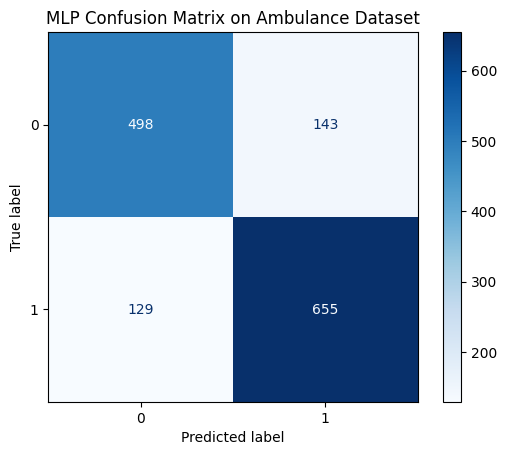

In [4]:
from ml import MultilayerPerceptron, train_test_split_arrays, standardize_vectors
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 6. Standardize features ---
X = standardize_vectors(X)

# --- 7. Train-test split ---
X_train, y_train, X_test, y_test = train_test_split_arrays(
    X, y_onehot, train_ratio=0.7, seed=42
)
y_test_labels = np.argmax(y_test, axis=1)

# --- 8. Build MLP ---
mlp = MultilayerPerceptron(
    layers=[
        (X_train.shape[1], 128, "relu"),   # hidden layer 1
        (128, 64, "relu"),                 # hidden layer 2
        (64, n_classes, "softmax")         # output layer matches one-hot labels
    ],
    learning_rate=0.01,
    loss_fn="mse"
)

# --- 9. Train ---
mlp.fit(X_train, y_train, epochs=100, verbose=True, stochastic= False)

# --- 10. Predict ---
y_pred = mlp.predict(X_test)

print("Predictions:", y_pred[:20])       # show first 20 predictions
print("True labels:", y_test_labels[:20])

# --- 11. Confusion matrix ---
cm = confusion_matrix(y_test_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("MLP Confusion Matrix on Ambulance Dataset")
plt.show()



In [11]:
print("X shape:", X.shape)

# Check for NaN or inf
print("Any NaN in X?", np.isnan(X).any())
print("Any +inf in X?", np.isposinf(X).any())
print("Any -inf in X?", np.isneginf(X).any())

# Check ranges
print("Min value in X:", np.min(X))
print("Max value in X:", np.max(X))


X shape: (4749, 12288)
Any NaN in X? False
Any +inf in X? False
Any -inf in X? False
Min value in X: -1.9999286
Max value in X: 3.0581653
